In [13]:
import pandas as pd 
import numpy as np


In [14]:
df = pd.read_csv("placement.csv")

In [15]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [16]:
df.shape

(100, 4)

In [17]:
# preprocessing the dataframe + EDA + Feature Selection 
# Extract input and output cols
# Scale the values => get the value in a scale of 0 to 1
# Train Test SPlit 
# Train The model 
# Evaluate the model / model evaluation 
# Deploy the model 

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [19]:
df = df.iloc[:,1:]

In [20]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


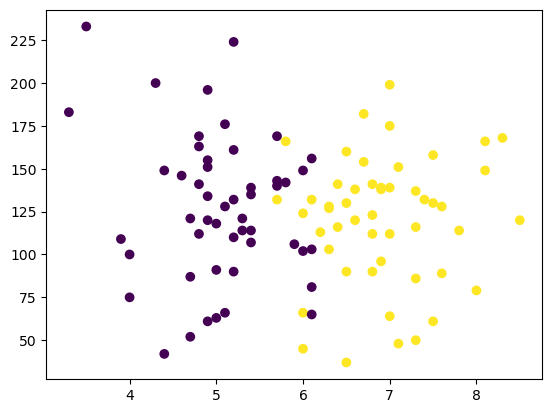

In [21]:
## EDA 
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'],df['iq'],c= df['placement'])

In [22]:
# feature selection 

# there are two features cgpa and iq


# seperate independent and dependent variable in the data set
# to extract input and output column

In [24]:
# x = independent variable 

x= df.iloc[:,0:2]
y= df.iloc[:,-1]

In [27]:
x.shape


(100, 2)

In [28]:
y.shape

(100,)

In [35]:
### Train test split 

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size = 0.1)

,cgpa,iq
3,7.4,132.0
74,6.7,154.0
60,6.9,139.0
18,4.0,100.0
1,5.9,106.0
...,...,...
84,5.7,169.0
46,5.3,114.0
22,4.9,120.0
67,5.0,118.0


In [33]:
x_test

,cgpa,iq
45,6.0,66.0
57,6.5,130.0
10,6.0,45.0
83,7.5,130.0
65,8.1,166.0
41,5.4,114.0
96,4.4,42.0
81,5.4,107.0
25,5.0,91.0
35,6.8,90.0


In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [41]:
x_train = scaler.fit_transform(x_train)
x_train

array([[ 0.71347685, -0.85316658],
       [-0.27997193,  0.47590089],
       [ 0.5328498 ,  0.35051716],
       [ 1.43598506,  0.09974972],
       [-1.45404776, -2.05685033],
       [-0.64122603, -0.25132471],
       [ 0.5328498 , -0.10086424],
       [ 0.26190922, -0.5271689 ],
       [-0.00903135, -1.98162009],
       [-0.82185308,  0.09974972],
       [ 1.16504448, -1.85623637],
       [ 0.71347685,  0.4257474 ],
       [-1.09279366, -0.3014782 ],
       [-1.90561539, -0.37670843],
       [-0.73153956,  0.92728229],
       [ 1.25535801,  0.2000567 ],
       [-1.00248014,  0.67651485],
       [-0.09934488, -0.45193867],
       [-0.55091251,  0.27528693],
       [ 0.8941039 ,  0.37559391],
       [-0.1896584 ,  0.45082414],
       [ 1.88755269,  1.05266602],
       [-1.00248014, -0.10086424],
       [-1.81530187, -1.22931775],
       [ 0.44253628, -0.85316658],
       [-0.64122603, -0.0757875 ],
       [ 0.62316333,  0.75174508],
       [-0.91216661, -1.53023869],
       [ 0.98441743,

In [42]:
x_test = scaler.fit_transform(x_test)
x_test

array([[ 1.07894191, -0.09401561],
       [-0.81649658,  0.03656163],
       [-0.59779214, -0.74690179],
       [-1.83711731,  1.65571936],
       [ 0.20412415,  0.95060228],
       [ 0.13122266,  0.11490797],
       [ 0.86023747, -1.45201887],
       [ 1.80795671,  1.26398765],
       [-0.30618622, -0.32905464],
       [-0.52489066, -1.39978797]])

In [43]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [52]:
#model training
clf.fit(x_train,y_train)

LogisticRegression()

In [63]:
# evaluate the model

y_pred = clf.predict(x_test)
y_pred

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0])

In [64]:
y_test


72    1
24    0
25    0
17    0
8     0
27    1
64    1
53    1
81    0
9     0
Name: placement, dtype: int64

In [61]:
from sklearn.metrics import accuracy_score 
accuracy_score(y_test,y_pred)

0.9

In [ ]:
# how to plot the decision boundary 


In [66]:
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 2.8 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 1.6 MB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.7 MB/s eta 0:00:00


<Axes: >

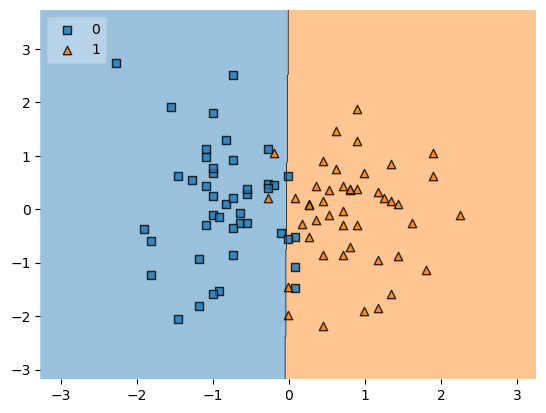

In [70]:
plot_decision_regions(x_train,y_train.values,clf = clf , legend =2)

<Axes: >

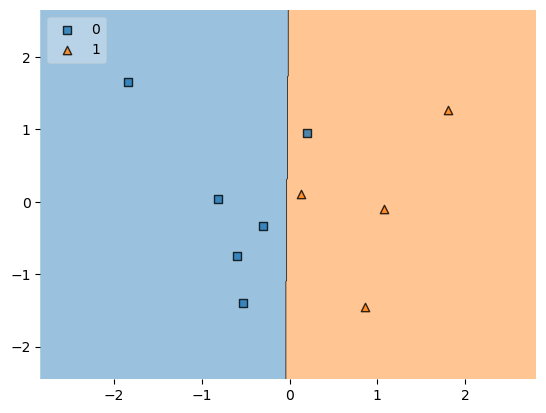

In [69]:
plot_decision_regions(x_test,y_test.values,clf = clf , legend =2)

In [72]:
import pickle


In [73]:
pickle.dump(clf,open('model.pkl','wb'))